In [83]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/syedaeman2212/chocolate-sales-dataset-in-2025/chocolate_sales_2025_dataset.csv


In [84]:
import pandas as pd
import matplotlib.pyplot as plt          
import seaborn as sns
import numpy as np
from io import StringIO

In [85]:
df = pd.read_csv("/kaggle/input/datasets/syedaeman2212/chocolate-sales-dataset-in-2025/chocolate_sales_2025_dataset.csv")

In [86]:
print(df.head())

   Sale_ID        Date      Brand    Product_Type    Country  \
0        1  2025-11-24    Cadbury  Milk Chocolate     France   
1        2  2025-02-22      Lindt   Chocolate Bar      India   
2        3  2025-02-17  Toblerone  Dark Chocolate  Australia   
3        4  2025-11-29    Ferrero        Truffles      Italy   
4        5  2025-03-23    Cadbury  Milk Chocolate     France   

       Sales_Channel  Payment_Method  Price_USD  Units_Sold  Revenue_USD  
0        Supermarket  Digital Wallet       5.00         194       970.00  
1             Online            Cash      17.73         144      2553.12  
2        Supermarket  Digital Wallet       7.42         134       994.28  
3  Convenience Store            Cash      18.28         112      2047.36  
4  Convenience Store            Cash      18.21          92      1675.32  


In [87]:
df.tail() 

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
495,496,2025-08-11,Cadbury,Milk Chocolate,France,Specialty Store,Digital Wallet,6.03,30,180.90
496,497,2025-10-11,Toblerone,White Chocolate,UAE,Convenience Store,Cash,18.75,191,3581.25
497,498,2025-02-19,Toblerone,Truffles,Germany,Online,Card,3.62,151,546.62
498,499,2025-01-02,Nestle,Chocolate Box,Italy,Specialty Store,Cash,12.12,80,969.60
499,500,2025-02-19,Mars,White Chocolate,UK,Specialty Store,Cash,3.08,48,147.84


In [88]:
df.head() 

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Cadbury,Milk Chocolate,France,Supermarket,Digital Wallet,5.00,194,970.00
1,2,2025-02-22,Lindt,Chocolate Bar,India,Online,Cash,17.73,144,2553.12
2,3,2025-02-17,Toblerone,Dark Chocolate,Australia,Supermarket,Digital Wallet,7.42,134,994.28
3,4,2025-11-29,Ferrero,Truffles,Italy,Convenience Store,Cash,18.28,112,2047.36
4,5,2025-03-23,Cadbury,Milk Chocolate,France,Convenience Store,Cash,18.21,92,1675.32


In [89]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         500 non-null    int64  
 1   Date            500 non-null    object 
 2   Brand           500 non-null    object 
 3   Product_Type    500 non-null    object 
 4   Country         500 non-null    object 
 5   Sales_Channel   500 non-null    object 
 6   Payment_Method  500 non-null    object 
 7   Price_USD       500 non-null    float64
 8   Units_Sold      500 non-null    int64  
 9   Revenue_USD     500 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB
None


In [90]:
print(df.describe())

          Sale_ID   Price_USD  Units_Sold  Revenue_USD
count  500.000000  500.000000  500.000000   500.000000
mean   250.500000   13.779860  104.938000  1433.391140
std    144.481833    6.484013   56.263998  1065.679386
min      1.000000    2.520000    5.000000    20.480000
25%    125.750000    8.592500   56.750000   562.545000
50%    250.500000   13.480000  108.500000  1197.225000
75%    375.250000   19.445000  150.250000  2072.812500
max    500.000000   25.000000  200.000000  4809.260000


In [91]:
total_revenue = df['Revenue_USD'].sum() 
print(f"\nTotal Revenue: ${total_revenue:,.2f}")


Total Revenue: $716,695.57


In [92]:
total_units = df['Units_Sold'].sum()

print(f"Total Units Sold: {total_units:,.0f}")

Total Units Sold: 52,469


In [93]:
# Revenue by country
revenue_by_country = df.groupby('Country')['Revenue_USD'].sum().sort_values(ascending=False)
print("\nRevenue by Country:")
print(revenue_by_country)


Revenue by Country:
Country
France          89956.88
Canada          80937.24
India           77033.35
UK              76796.23
Germany         74267.03
Saudi Arabia    71646.47
Italy           68370.53
Australia       64400.55
UAE             59204.41
USA             54082.88
Name: Revenue_USD, dtype: float64


In [94]:
# Revenue by brand
revenue_by_brand = df.groupby('Brand')['Revenue_USD'].sum().sort_values(ascending=False)
print("\nRevenue by Brand:")
print(revenue_by_brand)


Revenue by Brand:
Brand
Toblerone    118291.29
Mars         115337.39
Lindt        106042.48
Nestle       100439.80
Ferrero       93826.16
Cadbury       91669.72
Hershey       91088.73
Name: Revenue_USD, dtype: float64


In [95]:
revenue_by_product = df.groupby('Product_Type')['Revenue_USD'].sum().sort_values(ascending=False)
print("\nRevenue by Product Type:")
print(revenue_by_product)


Revenue by Product Type:
Product_Type
Chocolate Box      151378.86
Milk Chocolate     119985.58
Truffles           116117.81
Chocolate Bar      114664.97
Dark Chocolate     108655.80
White Chocolate    105892.55
Name: Revenue_USD, dtype: float64


In [96]:
revenue_by_channel = df.groupby('Sales_Channel')['Revenue_USD'].sum().sort_values(ascending=False)
print("\nRevenue by Sales Channel:")
print(revenue_by_channel)


Revenue by Sales Channel:
Sales_Channel
Convenience Store    200001.57
Specialty Store      180633.82
Supermarket          179683.38
Online               156376.80
Name: Revenue_USD, dtype: float64


In [97]:
revenue_by_payment = df.groupby('Payment_Method')['Revenue_USD'].sum().sort_values(ascending=False)
print("\nRevenue by Payment Method:")
print(revenue_by_payment)


Revenue by Payment Method:
Payment_Method
Digital Wallet    248348.48
Cash              244688.26
Card              223658.83
Name: Revenue_USD, dtype: float64


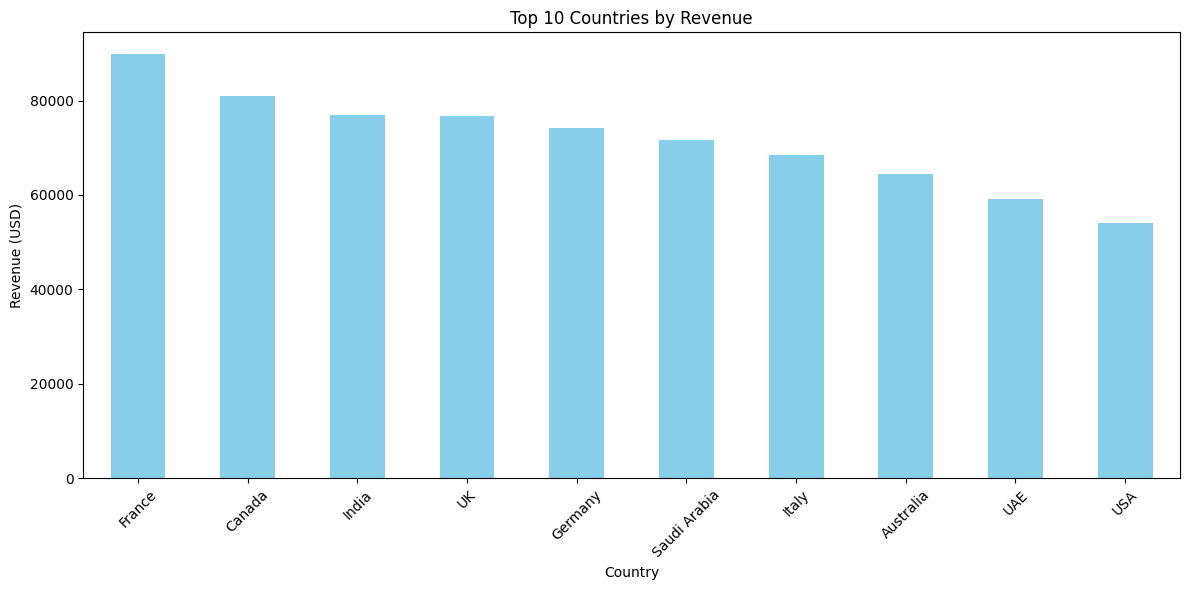

In [98]:
plt.figure(figsize=(12,6))
revenue_by_country.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue (USD)')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

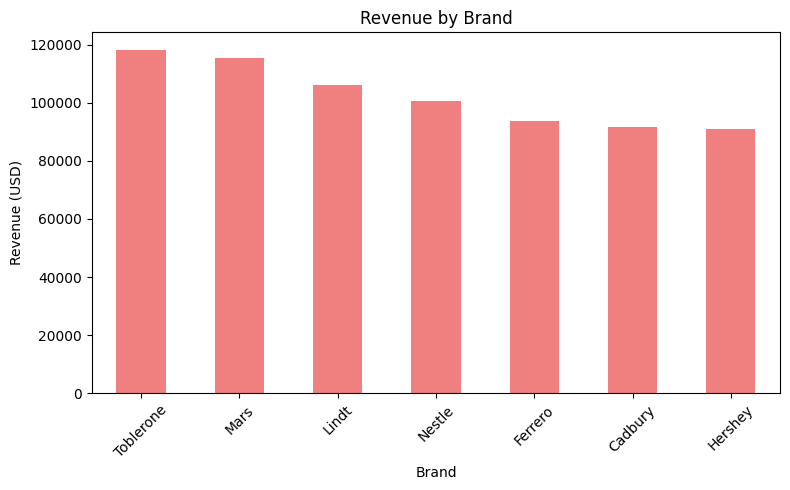

In [99]:
plt.figure(figsize=(8,5))
revenue_by_brand.plot(kind='bar', color='lightcoral')
plt.title('Revenue by Brand')
plt.ylabel('Revenue (USD)')
plt.xlabel('Brand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [100]:
df['Date'] = pd.to_datetime(df['Date'])

In [101]:
print("Dataset shape:", df.shape) 

Dataset shape: (500, 10)


In [102]:
print(df.dtypes)

Sale_ID                    int64
Date              datetime64[ns]
Brand                     object
Product_Type              object
Country                   object
Sales_Channel             object
Payment_Method            object
Price_USD                float64
Units_Sold                 int64
Revenue_USD              float64
dtype: object


In [103]:
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth')['Revenue_USD'].sum()

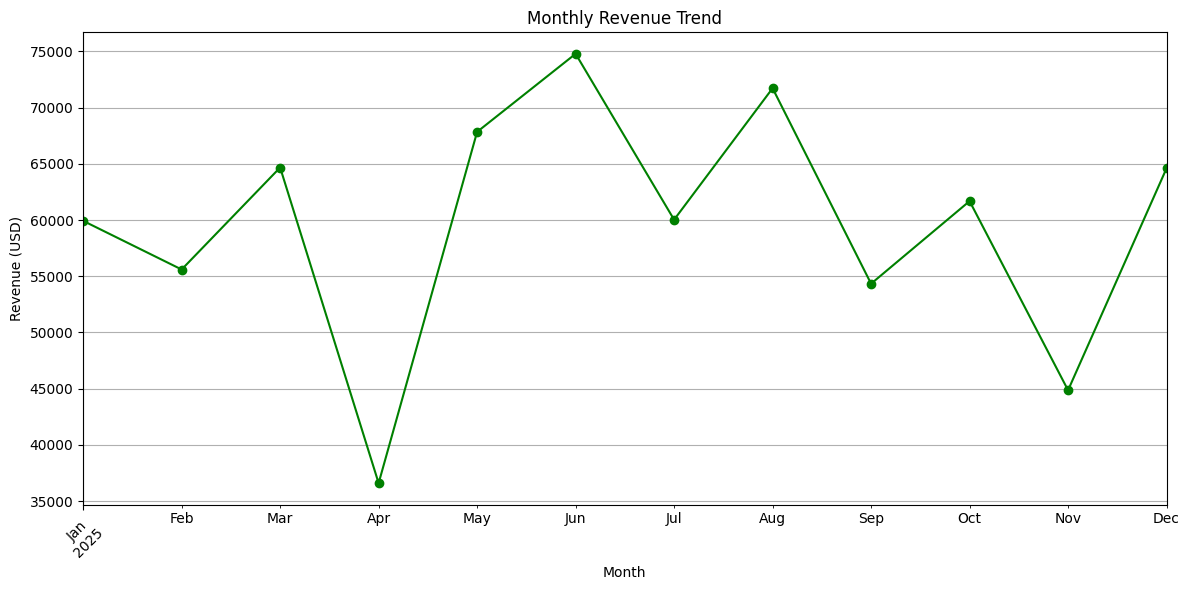

In [104]:
plt.figure(figsize=(12,6))
monthly_revenue.plot(marker='o', linestyle='-', color='green')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (USD)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [105]:
pivot_country_product = pd.pivot_table(df, values='Revenue_USD',
                                       index='Country', columns='Product_Type',
                                       aggfunc='sum', fill_value=0)
print("\nRevenue by Country and Product Type (top 5 countries by total):")
top_countries = df.groupby('Country')['Revenue_USD'].sum().nlargest(5).index
print(pivot_country_product.loc[top_countries])


Revenue by Country and Product Type (top 5 countries by total):
Product_Type  Chocolate Bar  Chocolate Box  Dark Chocolate  Milk Chocolate  \
Country                                                                      
France             15809.35       16170.40        19914.18        19168.17   
Canada             12614.52       14063.77         6386.08        17208.52   
India              17487.36       20762.96         8312.78        17731.74   
UK                  7675.91       22215.49         8120.65         9668.37   
Germany            12684.34       16984.14        17387.59         6315.08   

Product_Type  Truffles  White Chocolate  
Country                                  
France         3758.40         15136.38  
Canada        21045.25          9619.10  
India          5502.56          7235.95  
UK            15089.25         14026.56  
Germany       13629.03          7266.85  


In [106]:
pivot_country_brand = pd.pivot_table(df, values='Revenue_USD',
                                     index='Country', columns='Brand',
                                     aggfunc='sum', fill_value=0)
print("\nRevenue by Country and Brand (top 5 countries):")
print(pivot_country_brand.loc[top_countries])


Revenue by Country and Brand (top 5 countries):
Brand     Cadbury   Ferrero   Hershey     Lindt      Mars    Nestle  Toblerone
Country                                                                       
France   20656.19   7986.02  14939.91  17564.80  10805.36   9515.13    8489.47
Canada   13794.90   9418.91   6607.64   8237.42  11287.77  19936.52   11654.08
India     7600.22  18472.43   1495.10   9907.81  18644.75   5611.52   15301.52
UK        9406.91   7236.39  10218.13  12446.76  24840.04   1605.15   11042.85
Germany   8231.05   4941.41   9250.22  11776.49  18450.37   7246.46   14371.03


In [107]:
channel_payment_ct = pd.crosstab(df['Sales_Channel'], df['Payment_Method'])
print("\nTransaction count by Sales Channel and Payment Method:")
print(channel_payment_ct)


Transaction count by Sales Channel and Payment Method:
Payment_Method     Card  Cash  Digital Wallet
Sales_Channel                                
Convenience Store    44    54              43
Online               38    32              40
Specialty Store      45    45              37
Supermarket          35    38              49


In [108]:
channel_payment_rev = pd.pivot_table(df, values='Revenue_USD',
                                     index='Sales_Channel', columns='Payment_Method',
                                     aggfunc='sum', fill_value=0)
print("\nRevenue by Sales Channel and Payment Method:")
print(channel_payment_rev)


Revenue by Sales Channel and Payment Method:
Payment_Method         Card      Cash  Digital Wallet
Sales_Channel                                        
Convenience Store  52886.57  85626.91        61488.09
Online             46210.32  44271.35        65895.13
Specialty Store    71888.51  59940.48        48804.83
Supermarket        52673.43  54849.52        72160.43


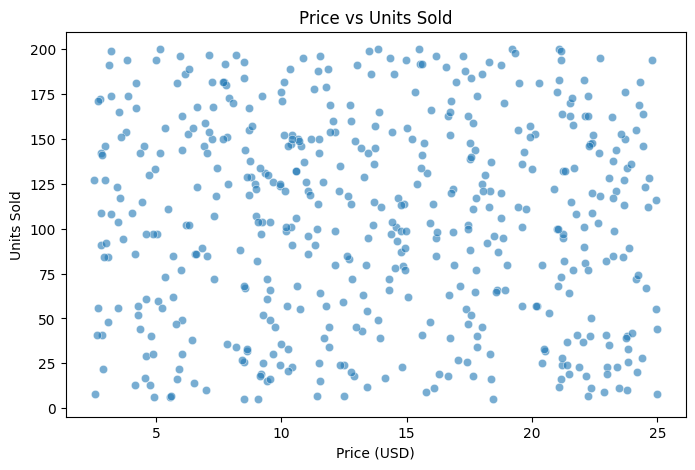

In [109]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Price_USD', y='Units_Sold', alpha=0.6)
plt.title('Price vs Units Sold')
plt.xlabel('Price (USD)')
plt.ylabel('Units Sold')
plt.show()

In [110]:
corr = df['Price_USD'].corr(df['Units_Sold'])
print(f"\nCorrelation between Price and Units Sold: {corr:.3f}")


Correlation between Price and Units Sold: -0.035


In [111]:
def top_products_per_country(df, n=3):
    top_products = df.groupby(['Country', 'Product_Type'])['Revenue_USD'].sum().reset_index()
    top_products = top_products.sort_values(['Country', 'Revenue_USD'], ascending=[True, False])
    return top_products.groupby('Country').head(n)

print("\nTop 3 product types by revenue in each country:")
print(top_products_per_country(df, 3).to_string(index=False))


Top 3 product types by revenue in each country:
     Country    Product_Type  Revenue_USD
   Australia  Dark Chocolate     13837.68
   Australia        Truffles     13063.45
   Australia   Chocolate Box     12211.60
      Canada        Truffles     21045.25
      Canada  Milk Chocolate     17208.52
      Canada   Chocolate Box     14063.77
      France  Dark Chocolate     19914.18
      France  Milk Chocolate     19168.17
      France   Chocolate Box     16170.40
     Germany  Dark Chocolate     17387.59
     Germany   Chocolate Box     16984.14
     Germany        Truffles     13629.03
       India   Chocolate Box     20762.96
       India  Milk Chocolate     17731.74
       India   Chocolate Bar     17487.36
       Italy White Chocolate     16730.73
       Italy  Dark Chocolate     13974.13
       Italy        Truffles     11745.31
Saudi Arabia   Chocolate Box     15903.17
Saudi Arabia        Truffles     12783.77
Saudi Arabia  Milk Chocolate     12780.72
         UAE        Truffle

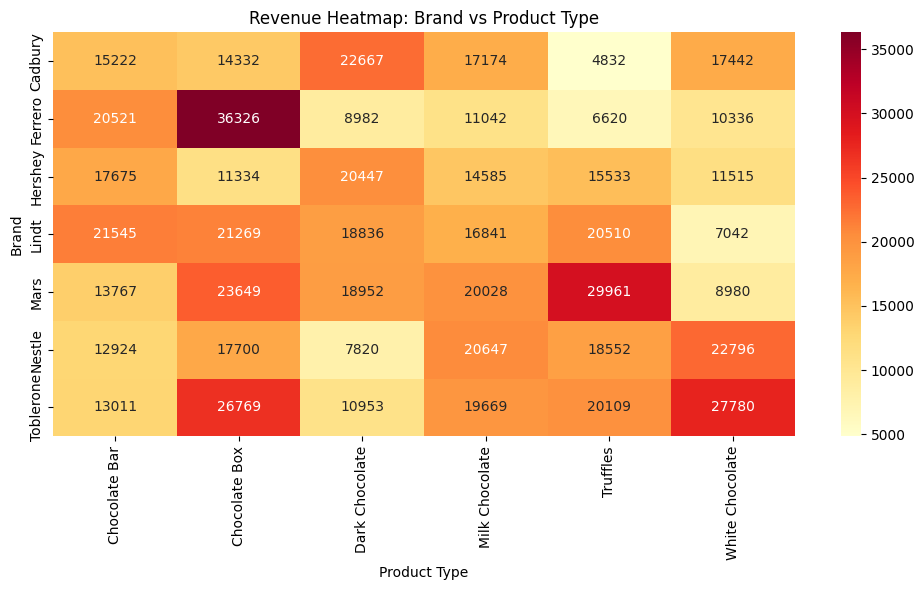

In [112]:
brand_product_pivot = pd.pivot_table(df, values='Revenue_USD',
                                     index='Brand', columns='Product_Type',
                                     aggfunc='sum', fill_value=0)

plt.figure(figsize=(10,6))
sns.heatmap(brand_product_pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Revenue Heatmap: Brand vs Product Type')
plt.ylabel('Brand')
plt.xlabel('Product Type')
plt.tight_layout()
plt.show()

In [113]:
avg_price_product = df.groupby('Product_Type')['Price_USD'].mean().sort_values()
print("\nAverage price by product type:")
print(avg_price_product)


Average price by product type:
Product_Type
Milk Chocolate     13.061839
White Chocolate    13.637083
Chocolate Bar      13.812771
Truffles           14.021084
Chocolate Box      14.063474
Dark Chocolate     14.068000
Name: Price_USD, dtype: float64


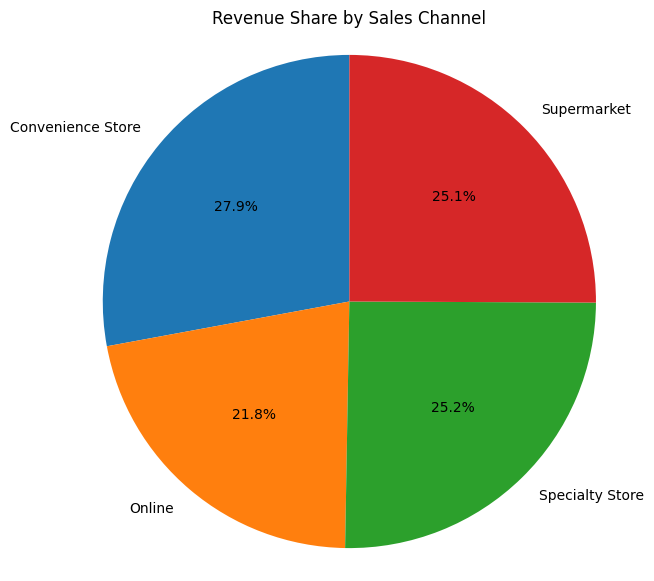

In [114]:
channel_revenue = df.groupby('Sales_Channel')['Revenue_USD'].sum()
plt.figure(figsize=(7,7))
plt.pie(channel_revenue, labels=channel_revenue.index, autopct='%1.1f%%', startangle=90)
plt.title('Revenue Share by Sales Channel')
plt.axis('equal')
plt.show()


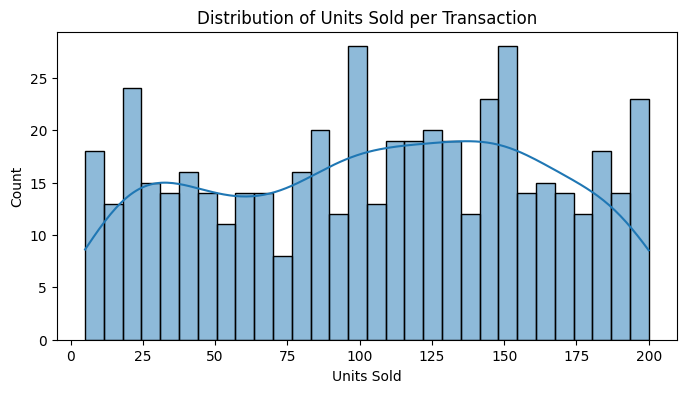

In [115]:
plt.figure(figsize=(8,4))
sns.histplot(df['Units_Sold'], bins=30, kde=True)
plt.title('Distribution of Units Sold per Transaction')
plt.xlabel('Units Sold')
plt.show()

In [116]:
top_units = df.groupby(['Country', 'Product_Type'])['Units_Sold'].sum().reset_index()
top_units = top_units.sort_values(['Country', 'Units_Sold'], ascending=[True, False])
top_units = top_units.groupby('Country').head(3)
print("Top 3 product types by units sold in each country:")
print(top_units.to_string(index=False))

Top 3 product types by units sold in each country:
     Country    Product_Type  Units_Sold
   Australia  Dark Chocolate         972
   Australia        Truffles         944
   Australia   Chocolate Bar         873
      Canada        Truffles        1187
      Canada  Milk Chocolate        1119
      Canada   Chocolate Box        1077
      France   Chocolate Box        1620
      France  Milk Chocolate        1360
      France  Dark Chocolate        1245
     Germany        Truffles        1267
     Germany   Chocolate Bar        1163
     Germany   Chocolate Box        1095
       India   Chocolate Box        1230
       India  Milk Chocolate        1088
       India   Chocolate Bar        1056
       Italy White Chocolate        1311
       Italy  Milk Chocolate        1085
       Italy  Dark Chocolate         986
Saudi Arabia  Milk Chocolate        1186
Saudi Arabia        Truffles        1147
Saudi Arabia   Chocolate Box        1038
         UAE  Milk Chocolate        1160
      

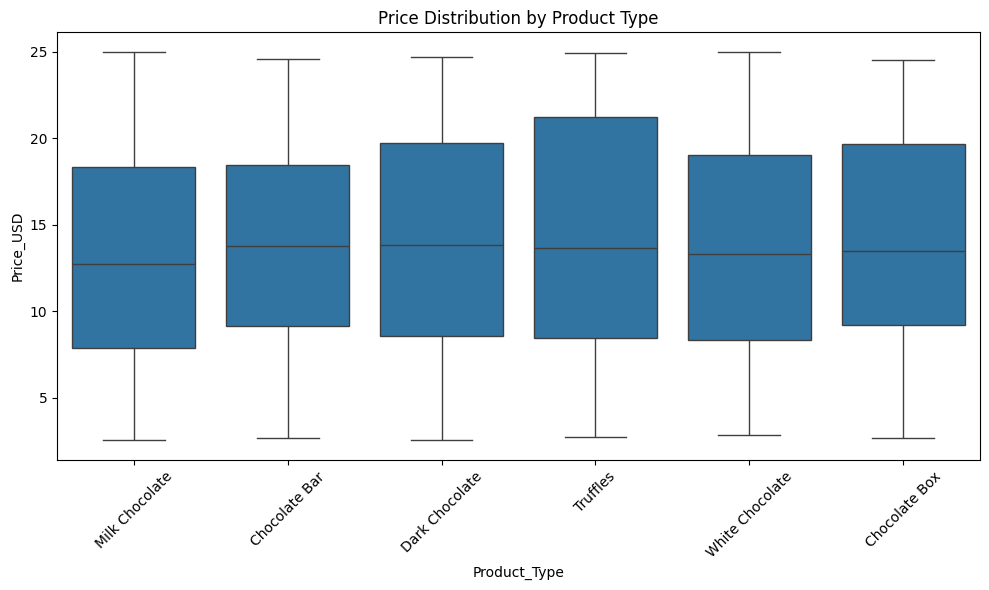

In [117]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Product_Type', y='Price_USD')
plt.title('Price Distribution by Product Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

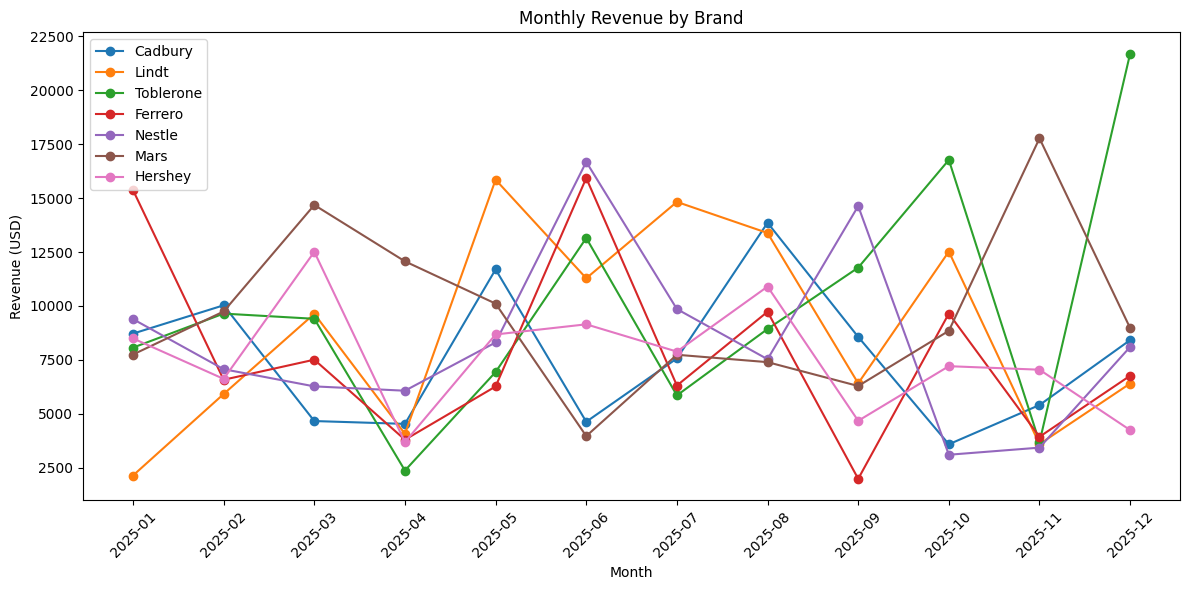

In [118]:

df['Month'] = df['Date'].dt.to_period('M')
brand_month = df.groupby(['Brand', 'Month'])['Revenue_USD'].sum().reset_index()

plt.figure(figsize=(12,6))
for brand in df['Brand'].unique():
    brand_data = brand_month[brand_month['Brand'] == brand]
    plt.plot(brand_data['Month'].astype(str), brand_data['Revenue_USD'], label=brand, marker='o')
plt.title('Monthly Revenue by Brand')
plt.xlabel('Month')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

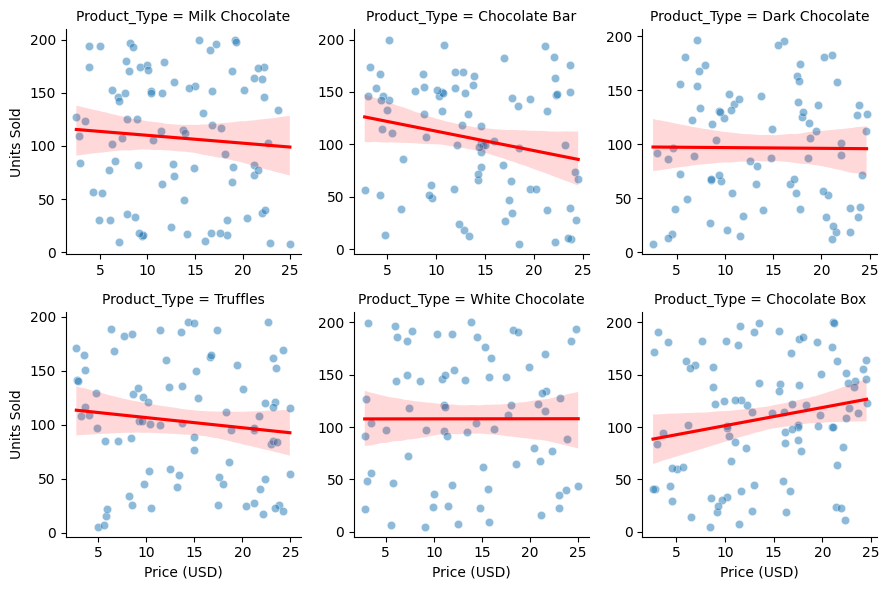

In [119]:

g = sns.FacetGrid(df, col='Product_Type', col_wrap=3, height=3, sharex=False, sharey=False)
g.map(sns.scatterplot, 'Price_USD', 'Units_Sold', alpha=0.5)
g.map(sns.regplot, 'Price_USD', 'Units_Sold', scatter=False, color='red')
g.set_axis_labels('Price (USD)', 'Units Sold')
plt.tight_layout()
plt.show()

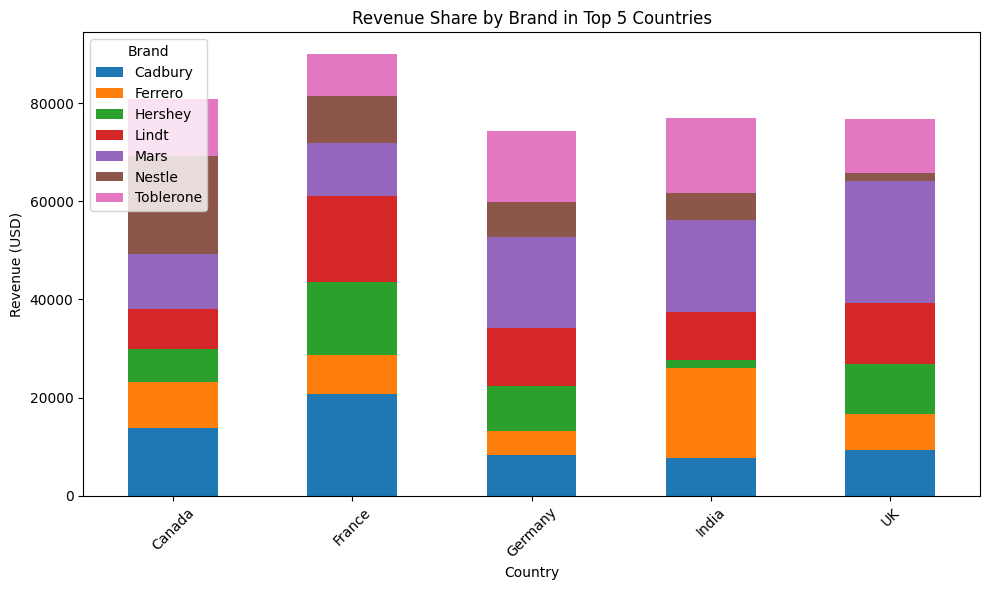

In [120]:

top5_countries = df.groupby('Country')['Revenue_USD'].sum().nlargest(5).index
country_brand = df[df['Country'].isin(top5_countries)].pivot_table(
    index='Country', columns='Brand', values='Revenue_USD', aggfunc='sum', fill_value=0
)
country_brand.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Revenue Share by Brand in Top 5 Countries')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=45)
plt.legend(title='Brand')
plt.tight_layout()
plt.show()

In [121]:
df['MonthNum'] = df['Date'].dt.month
month_product = df.groupby(['MonthNum', 'Product_Type'])['Revenue_USD'].sum().reset_index()
best_month = month_product.loc[month_product.groupby('Product_Type')['Revenue_USD'].idxmax()]
print("Best month (by revenue) for each product type:")
print(best_month[['Product_Type', 'MonthNum', 'Revenue_USD']].sort_values('Product_Type'))

Best month (by revenue) for each product type:
       Product_Type  MonthNum  Revenue_USD
6     Chocolate Bar         2     17773.03
1     Chocolate Box         1     22352.80
31   Dark Chocolate         6     16829.24
62   Milk Chocolate        11     14401.80
57         Truffles        10     15533.35
40  White Chocolate         7     14214.18


In [122]:
avg_rev_per_trans = df['Revenue_USD'].mean()
avg_rev_per_unit = df['Revenue_USD'].sum() / df['Units_Sold'].sum()
print(f"Average revenue per transaction: ${avg_rev_per_trans:.2f}")
print(f"Average revenue per unit sold: ${avg_rev_per_unit:.2f}")

Average revenue per transaction: $1433.39
Average revenue per unit sold: $13.66


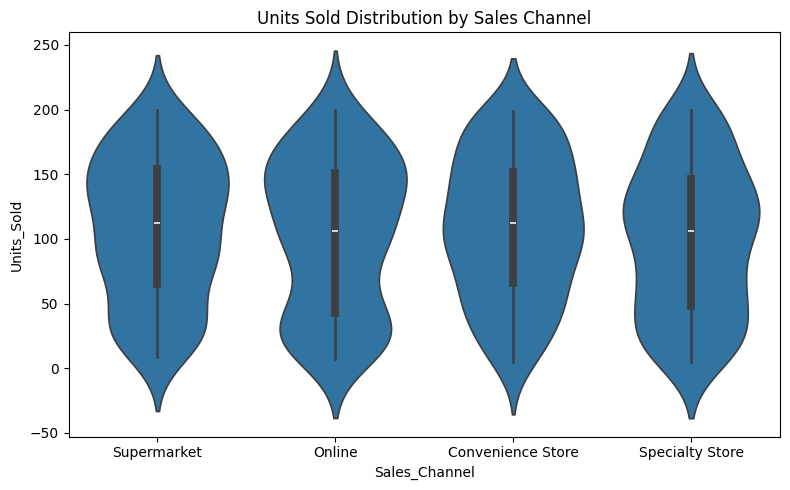

In [123]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='Sales_Channel', y='Units_Sold')
plt.title('Units Sold Distribution by Sales Channel')
plt.tight_layout()
plt.show()

In [124]:
print("Columns in df:", df.columns.tolist())
print(df.head())

Columns in df: ['Sale_ID', 'Date', 'Brand', 'Product_Type', 'Country', 'Sales_Channel', 'Payment_Method', 'Price_USD', 'Units_Sold', 'Revenue_USD', 'YearMonth', 'Month', 'MonthNum']
   Sale_ID       Date      Brand    Product_Type    Country  \
0        1 2025-11-24    Cadbury  Milk Chocolate     France   
1        2 2025-02-22      Lindt   Chocolate Bar      India   
2        3 2025-02-17  Toblerone  Dark Chocolate  Australia   
3        4 2025-11-29    Ferrero        Truffles      Italy   
4        5 2025-03-23    Cadbury  Milk Chocolate     France   

       Sales_Channel  Payment_Method  Price_USD  Units_Sold  Revenue_USD  \
0        Supermarket  Digital Wallet       5.00         194       970.00   
1             Online            Cash      17.73         144      2553.12   
2        Supermarket  Digital Wallet       7.42         134       994.28   
3  Convenience Store            Cash      18.28         112      2047.36   
4  Convenience Store            Cash      18.21          92

In [125]:
country_total = df.groupby('Country')['Revenue_USD'].transform('sum')
df['Country_Share'] = df['Revenue_USD'] / country_total * 100
brand_country_share = df.groupby(['Country','Brand'])['Country_Share'].sum().reset_index()
brand_country_share = brand_country_share.sort_values(['Country','Country_Share'], ascending=[True,False])
print(brand_country_share.head(20))  

      Country      Brand  Country_Share
5   Australia     Nestle      21.191667
0   Australia    Cadbury      19.947330
4   Australia       Mars      18.080544
2   Australia    Hershey      15.315397
6   Australia  Toblerone      11.624714
1   Australia    Ferrero      10.613139
3   Australia      Lindt       3.227208
12     Canada     Nestle      24.632073
7      Canada    Cadbury      17.043947
13     Canada  Toblerone      14.398910
11     Canada       Mars      13.946324
8      Canada    Ferrero      11.637301
10     Canada      Lindt      10.177540
9      Canada    Hershey       8.163906
14     France    Cadbury      22.962324
17     France      Lindt      19.525799
16     France    Hershey      16.607857
18     France       Mars      12.011710
19     France     Nestle      10.577434
20     France  Toblerone       9.437266


In [126]:
import statsmodels.api as sm
df_dark = df[df['Product_Type'] == 'Dark Chocolate'].copy()
df_dark['log_price'] = np.log(df_dark['Price_USD'])
df_dark['log_units'] = np.log(df_dark['Units_Sold'])
X = sm.add_constant(df_dark['log_price'])
model = sm.OLS(df_dark['log_units'], X).fit()
print(model.summary())  # coefficient of log_price is the elasticity

                            OLS Regression Results                            
Dep. Variable:              log_units   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.8956
Date:                Sat, 07 Mar 2026   Prob (F-statistic):              0.347
Time:                        08:18:10   Log-Likelihood:                -90.485
No. Observations:                  80   AIC:                             185.0
Df Residuals:                      78   BIC:                             189.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9914      0.392     10.191      0.0

In [127]:

top_n = 3
top_rev = df.groupby('Country')['Revenue_USD'].sum().nlargest(top_n).sum()
total_rev = df['Revenue_USD'].sum()
print(f"Top {top_n} countries contribute {top_rev/total_rev*100:.1f}% of total revenue.")

Top 3 countries contribute 34.6% of total revenue.


In [128]:
channel_product = pd.crosstab(df['Sales_Channel'], df['Product_Type'], values=df['Units_Sold'], aggfunc='sum', normalize='index') * 100
print("Percentage of units sold per channel by product type:")
print(channel_product.round(1))

Percentage of units sold per channel by product type:
Product_Type       Chocolate Bar  Chocolate Box  Dark Chocolate  \
Sales_Channel                                                     
Convenience Store           15.7           16.4            18.4   
Online                      13.1           29.3            14.1   
Specialty Store             17.9           19.1             7.9   
Supermarket                 19.7           15.4            17.6   

Product_Type       Milk Chocolate  Truffles  White Chocolate  
Sales_Channel                                                 
Convenience Store            19.1      11.6             18.7  
Online                        9.6      19.9             14.0  
Specialty Store              24.9      15.7             14.4  
Supermarket                  16.7      19.3             11.3  


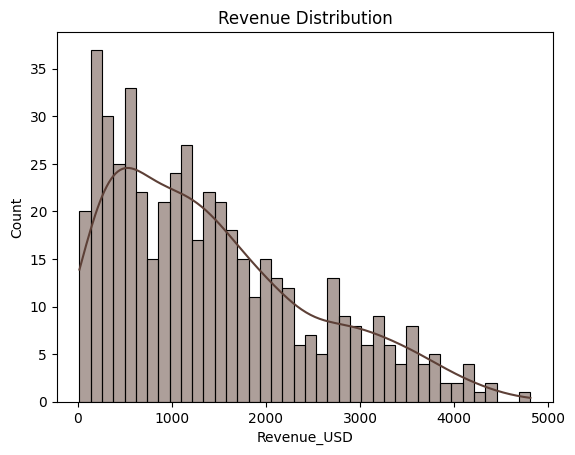

In [129]:
sns.histplot(df['Revenue_USD'],bins=40,color='#5d4037',kde=True)
plt.title("Revenue Distribution")
plt.show()

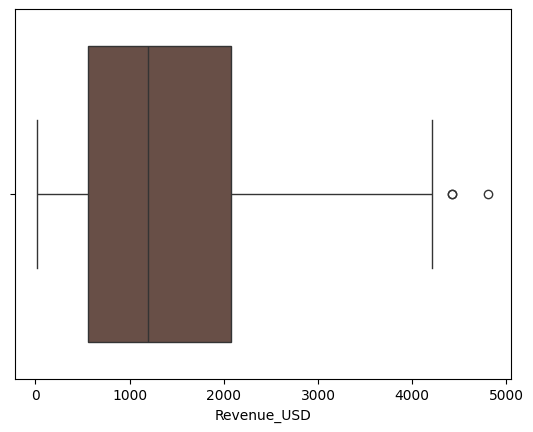

In [130]:
sns.boxplot(x=df['Revenue_USD'],color='#6d4c41')
plt.show()

/tmp/ipykernel_55/2229538591.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand.index,y=brand.values,palette="copper")


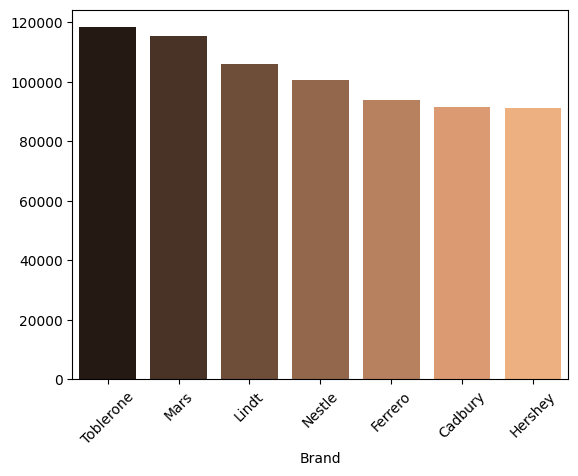

In [131]:
brand=df.groupby("Brand")["Revenue_USD"].sum().sort_values(ascending=False)
sns.barplot(x=brand.index,y=brand.values,palette="copper")
plt.xticks(rotation=45)
plt.show()

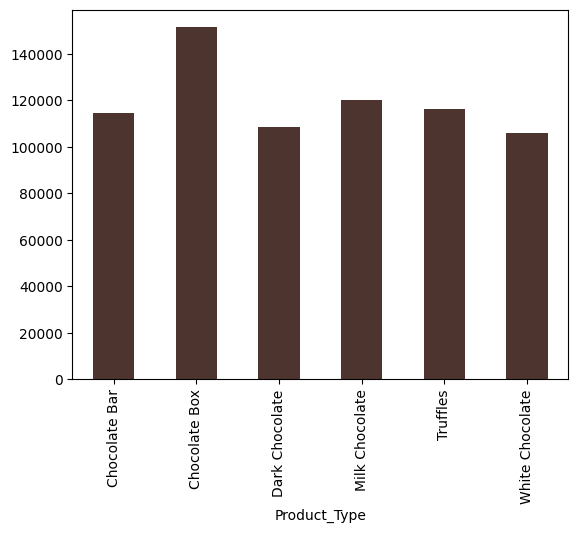

In [132]:
ptype=df.groupby("Product_Type")["Revenue_USD"].sum()
ptype.plot(kind="bar",color="#4e342e")
plt.show()

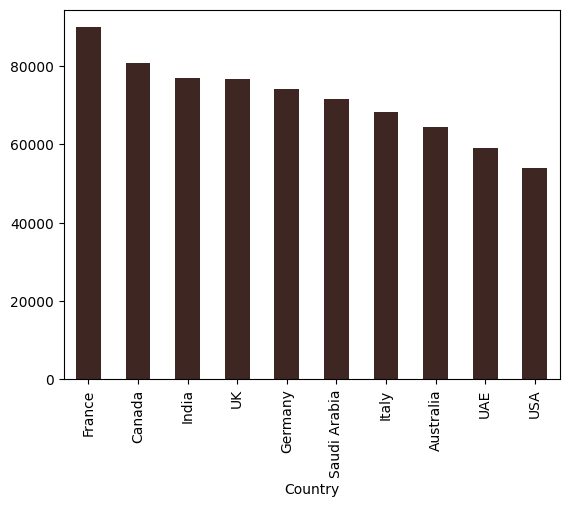

In [133]:
country=df.groupby("Country")["Revenue_USD"].sum().sort_values(ascending=False)
country.plot(kind="bar",color="#3e2723")
plt.show()

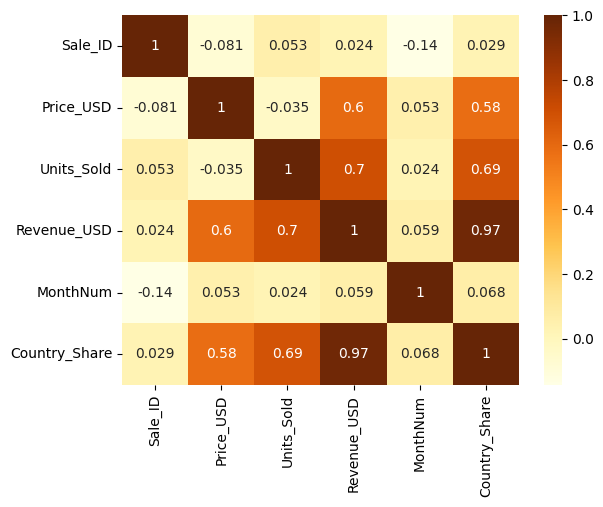

In [134]:
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap="YlOrBr")
plt.show()

In [135]:
print("Number of rows loaded:", len(df))
print(df.head())

Number of rows loaded: 500
   Sale_ID       Date      Brand    Product_Type    Country  \
0        1 2025-11-24    Cadbury  Milk Chocolate     France   
1        2 2025-02-22      Lindt   Chocolate Bar      India   
2        3 2025-02-17  Toblerone  Dark Chocolate  Australia   
3        4 2025-11-29    Ferrero        Truffles      Italy   
4        5 2025-03-23    Cadbury  Milk Chocolate     France   

       Sales_Channel  Payment_Method  Price_USD  Units_Sold  Revenue_USD  \
0        Supermarket  Digital Wallet       5.00         194       970.00   
1             Online            Cash      17.73         144      2553.12   
2        Supermarket  Digital Wallet       7.42         134       994.28   
3  Convenience Store            Cash      18.28         112      2047.36   
4  Convenience Store            Cash      18.21          92      1675.32   

  YearMonth    Month  MonthNum  Country_Share  
0   2025-11  2025-11        11       1.078294  
1   2025-02  2025-02         2       3.31

In [136]:
data = """Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
1,2025-11-24,Cadbury,Milk Chocolate,France,Supermarket,Digital Wallet,5.0,194,970.0
2,2025-02-22,Lindt,Chocolate Bar,India,Online,Cash,17.73,144,2553.12"""
df = pd.read_csv(StringIO(data))
print(df)

   Sale_ID        Date    Brand    Product_Type Country Sales_Channel  \
0        1  2025-11-24  Cadbury  Milk Chocolate  France   Supermarket   
1        2  2025-02-22    Lindt   Chocolate Bar   India        Online   

   Payment_Method  Price_USD  Units_Sold  Revenue_USD  
0  Digital Wallet       5.00         194       970.00  
1            Cash      17.73         144      2553.12  


In [137]:
csv_data = """Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
1,2025-11-24,Cadbury,Milk Chocolate,France,Supermarket,Digital Wallet,5.0,194,970.0
2,2025-02-22,Lindt,Chocolate Bar,India,Online,Cash,17.73,144,2553.12
... (all 500 lines) ..."""

In [138]:
print("Before conversion:")
print(df.head())
print(df.dtypes)

Before conversion:
   Sale_ID        Date    Brand    Product_Type Country Sales_Channel  \
0        1  2025-11-24  Cadbury  Milk Chocolate  France   Supermarket   
1        2  2025-02-22    Lindt   Chocolate Bar   India        Online   

   Payment_Method  Price_USD  Units_Sold  Revenue_USD  
0  Digital Wallet       5.00         194       970.00  
1            Cash      17.73         144      2553.12  
Sale_ID             int64
Date               object
Brand              object
Product_Type       object
Country            object
Sales_Channel      object
Payment_Method     object
Price_USD         float64
Units_Sold          int64
Revenue_USD       float64
dtype: object


In [139]:

df['Date'] = pd.to_datetime(df['Date'])

print("\nAfter conversion:")
print(df.dtypes)


After conversion:
Sale_ID                    int64
Date              datetime64[ns]
Brand                     object
Product_Type              object
Country                   object
Sales_Channel             object
Payment_Method            object
Price_USD                float64
Units_Sold                 int64
Revenue_USD              float64
dtype: object


In [140]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.month_name()
df['Weekday'] = df['Date'].dt.day_name()
df['WeekdayNum'] = df['Date'].dt.dayofweek

print("\nTime columns added successfully!")
print(df[['Date','Year','Month','MonthName','Weekday','WeekdayNum']].head())


Time columns added successfully!
        Date  Year  Month MonthName   Weekday  WeekdayNum
0 2025-11-24  2025     11  November    Monday           0
1 2025-02-22  2025      2  February  Saturday           5


In [141]:
total_revenue = df['Revenue_USD'].sum()
total_units = df['Units_Sold'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Units Sold: {total_units:,.0f}")

Total Revenue: $3,523.12
Total Units Sold: 338


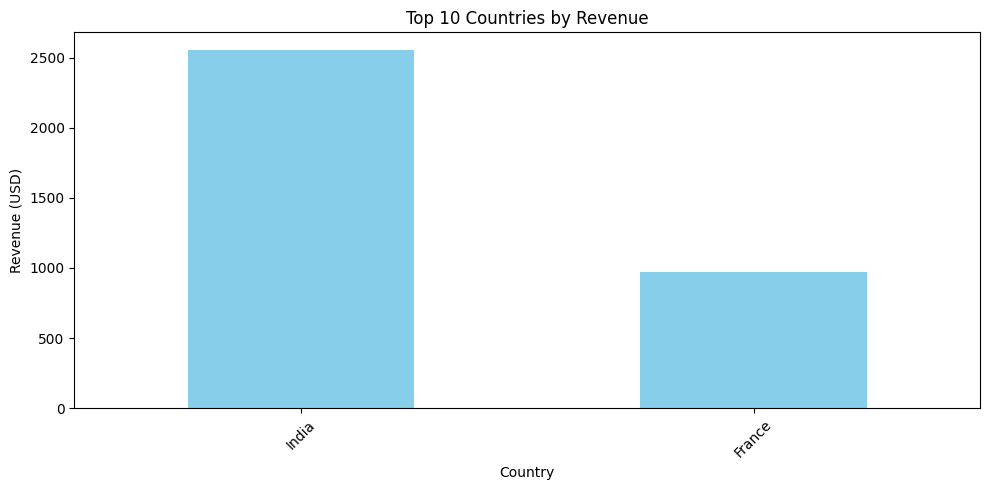

In [142]:
country_rev = df.groupby('Country')['Revenue_USD'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
country_rev.plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue (USD)')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

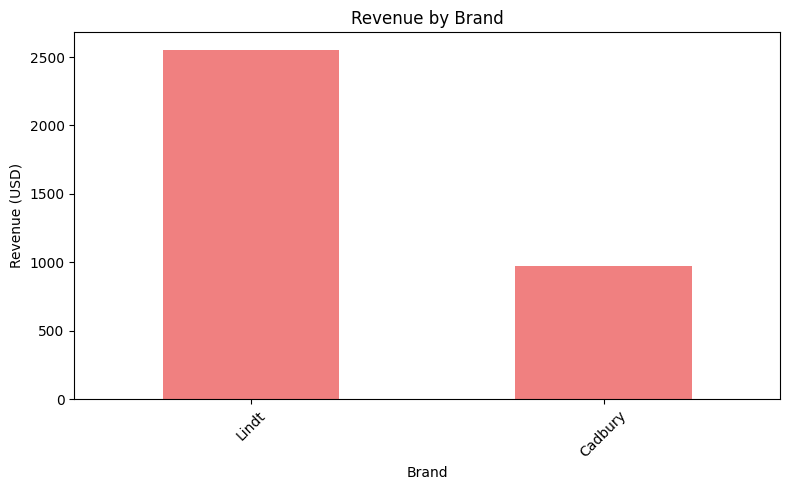

In [143]:
brand_rev = df.groupby('Brand')['Revenue_USD'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
brand_rev.plot(kind='bar', color='lightcoral')
plt.title('Revenue by Brand')
plt.ylabel('Revenue (USD)')
plt.xlabel('Brand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

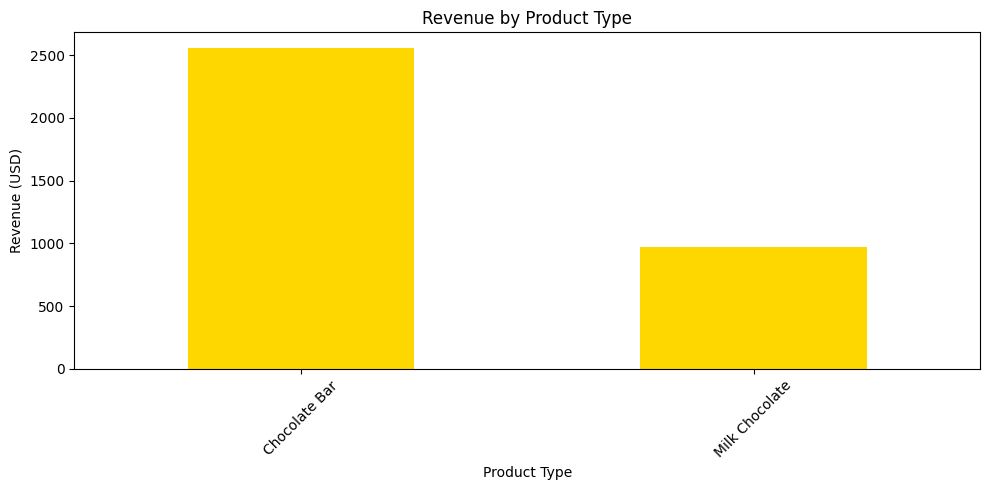

In [144]:
product_rev = df.groupby('Product_Type')['Revenue_USD'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
product_rev.plot(kind='bar', color='gold')
plt.title('Revenue by Product Type')
plt.ylabel('Revenue (USD)')
plt.xlabel('Product Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

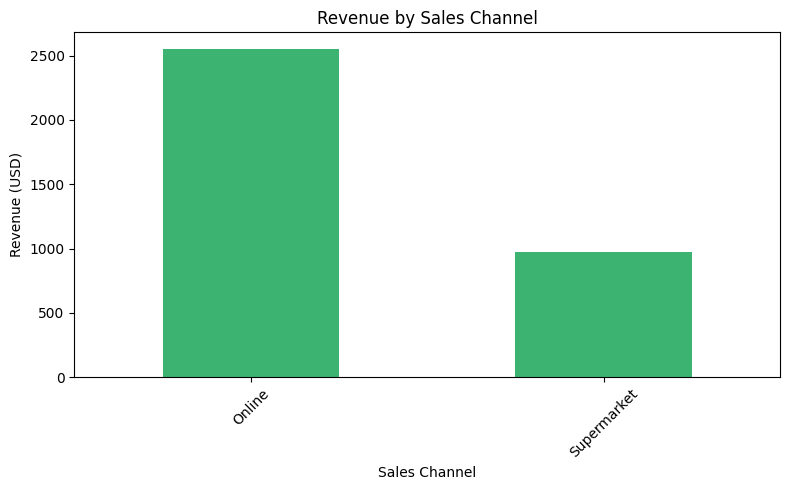

In [145]:
channel_rev = df.groupby('Sales_Channel')['Revenue_USD'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
channel_rev.plot(kind='bar', color='mediumseagreen')
plt.title('Revenue by Sales Channel')
plt.ylabel('Revenue (USD)')
plt.xlabel('Sales Channel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

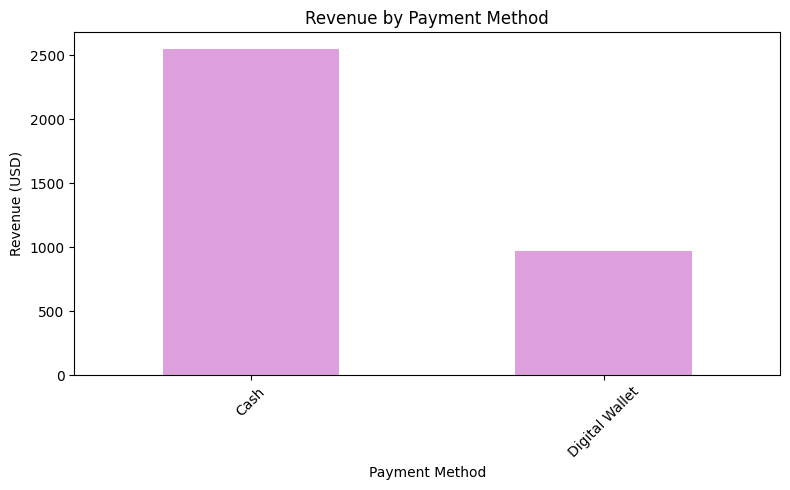

In [146]:
payment_rev = df.groupby('Payment_Method')['Revenue_USD'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
payment_rev.plot(kind='bar', color='plum')
plt.title('Revenue by Payment Method')
plt.ylabel('Revenue (USD)')
plt.xlabel('Payment Method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

(np.float64(-1.099998267010125),
 np.float64(1.0999992657033464),
 np.float64(-1.099995619781437),
 np.float64(1.0999997914181636))

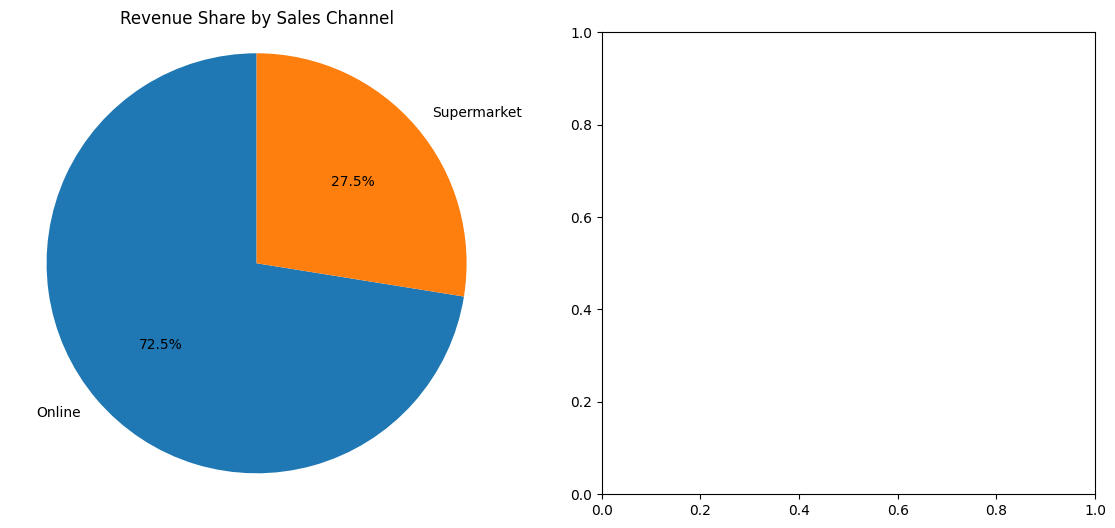

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].pie(channel_rev, labels=channel_rev.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Revenue Share by Sales Channel')
axes[0].axis('equal')

In [148]:
axes[1].pie(payment_rev, labels=payment_rev.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Revenue Share by Payment Method')
axes[1].axis('equal')
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

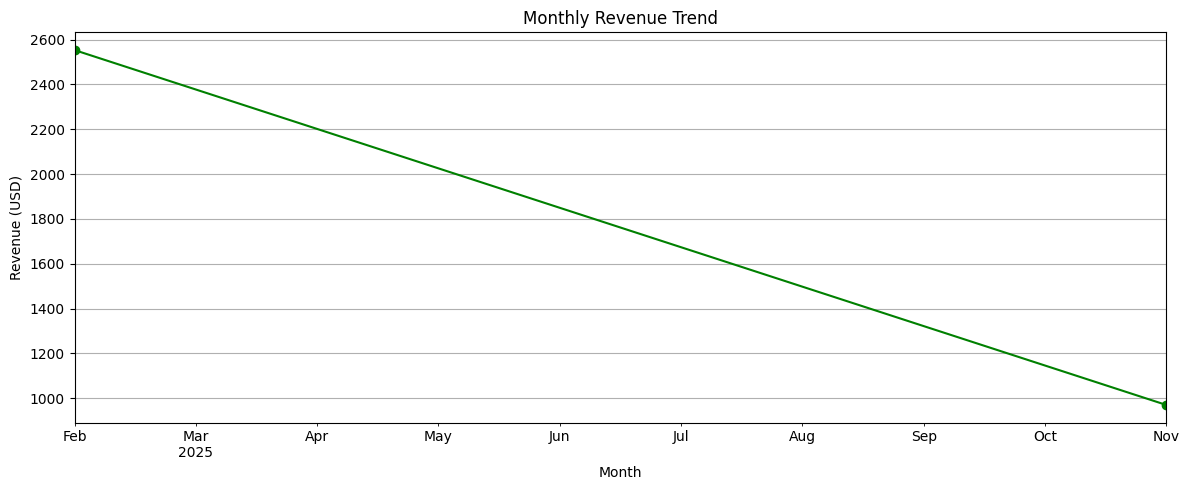

In [149]:
monthly_rev = df.groupby(df['Date'].dt.to_period('M'))['Revenue_USD'].sum()
plt.figure(figsize=(12,5))
monthly_rev.plot(marker='o', linestyle='-', color='green')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (USD)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

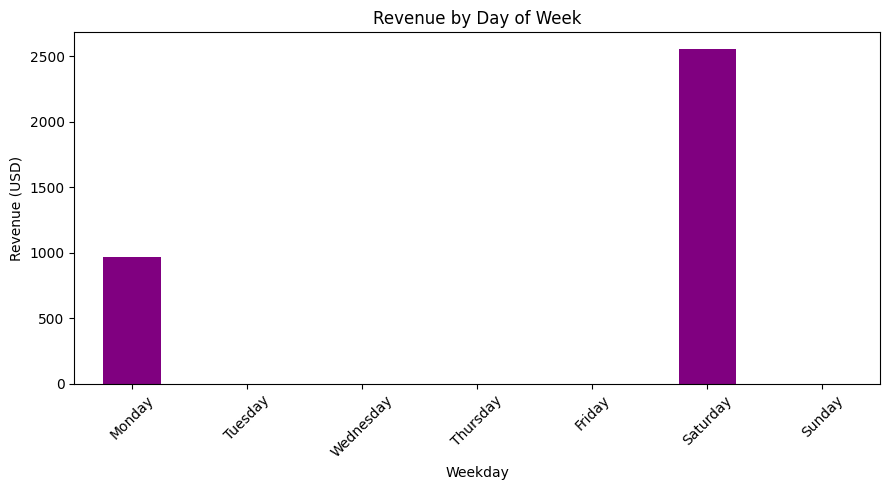

In [150]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_rev = df.groupby('Weekday')['Revenue_USD'].sum().reindex(weekday_order)
plt.figure(figsize=(9,5))
weekday_rev.plot(kind='bar', color='purple')
plt.title('Revenue by Day of Week')
plt.ylabel('Revenue (USD)')
plt.xlabel('Weekday')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


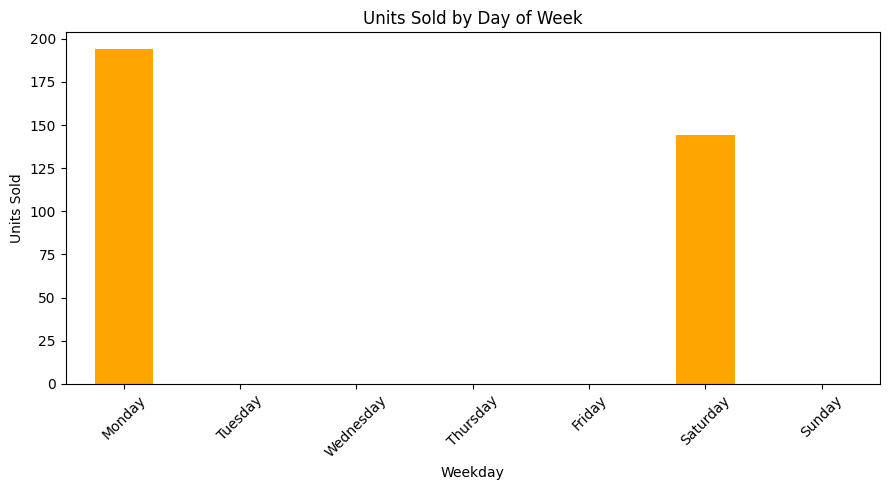

In [151]:
weekday_units = df.groupby('Weekday')['Units_Sold'].sum().reindex(weekday_order)
plt.figure(figsize=(9,5))
weekday_units.plot(kind='bar', color='orange')
plt.title('Units Sold by Day of Week')
plt.ylabel('Units Sold')
plt.xlabel('Weekday')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

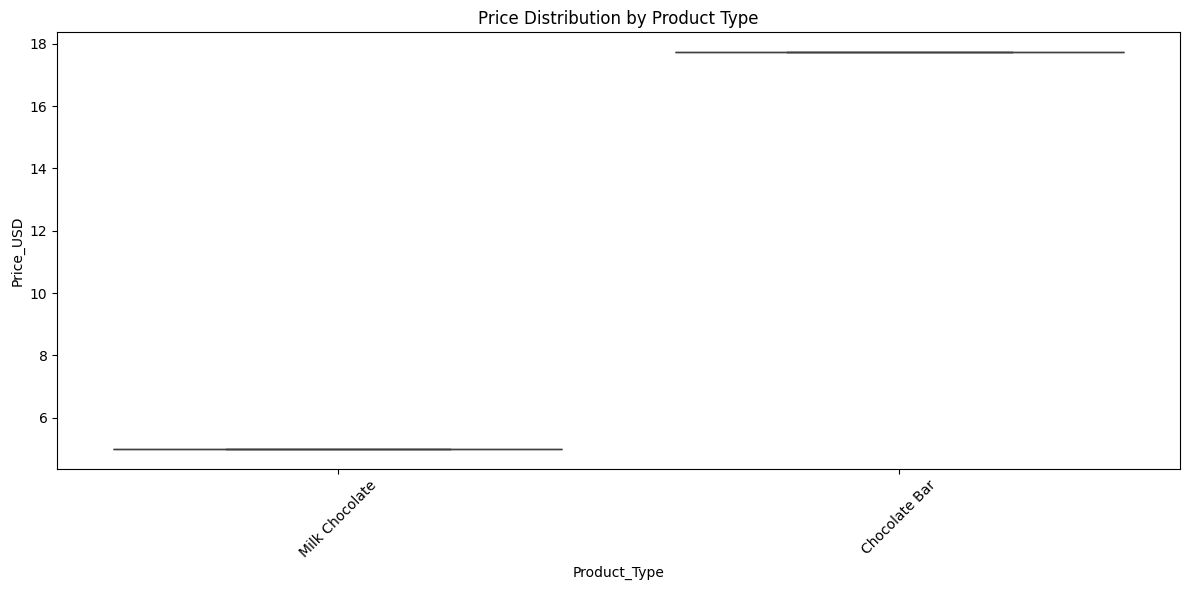

In [152]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Product_Type', y='Price_USD')
plt.title('Price Distribution by Product Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

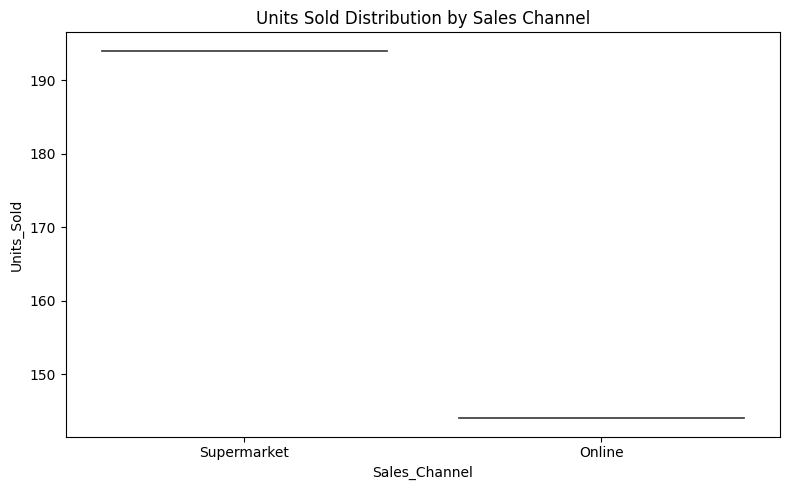

In [153]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='Sales_Channel', y='Units_Sold')
plt.title('Units Sold Distribution by Sales Channel')
plt.tight_layout()
plt.show()

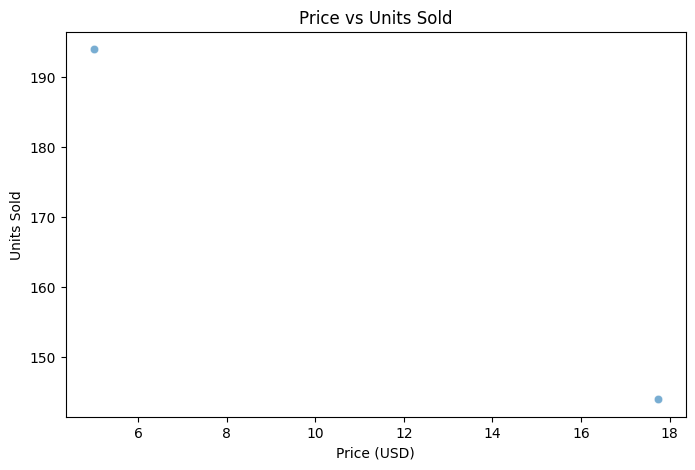

In [154]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Price_USD', y='Units_Sold', alpha=0.6)
plt.title('Price vs Units Sold')
plt.xlabel('Price (USD)')
plt.ylabel('Units Sold')
plt.show()


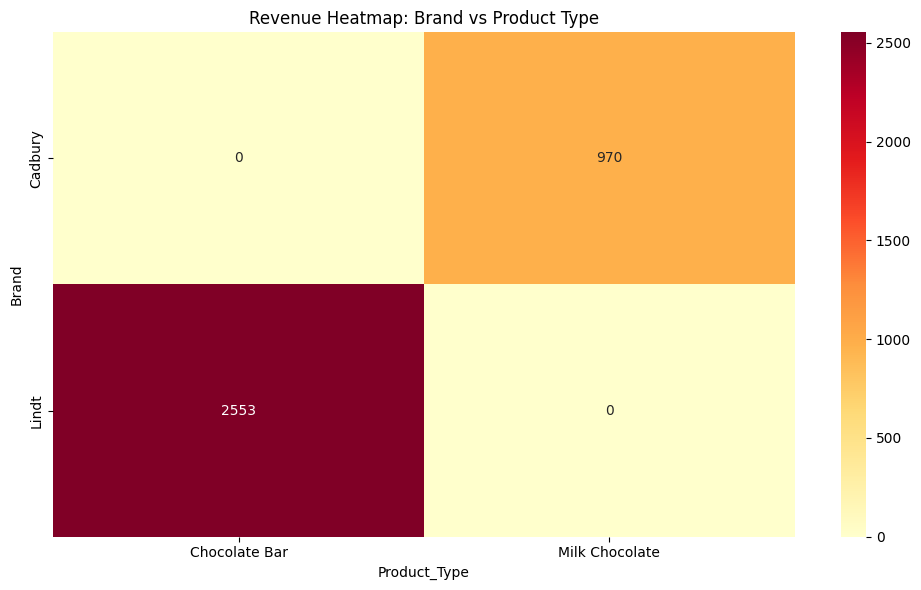

In [155]:
brand_product = pd.pivot_table(df, values='Revenue_USD',
                               index='Brand', columns='Product_Type',
                               aggfunc='sum', fill_value=0)
plt.figure(figsize=(10,6))
sns.heatmap(brand_product, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Revenue Heatmap: Brand vs Product Type')
plt.tight_layout()
plt.show()

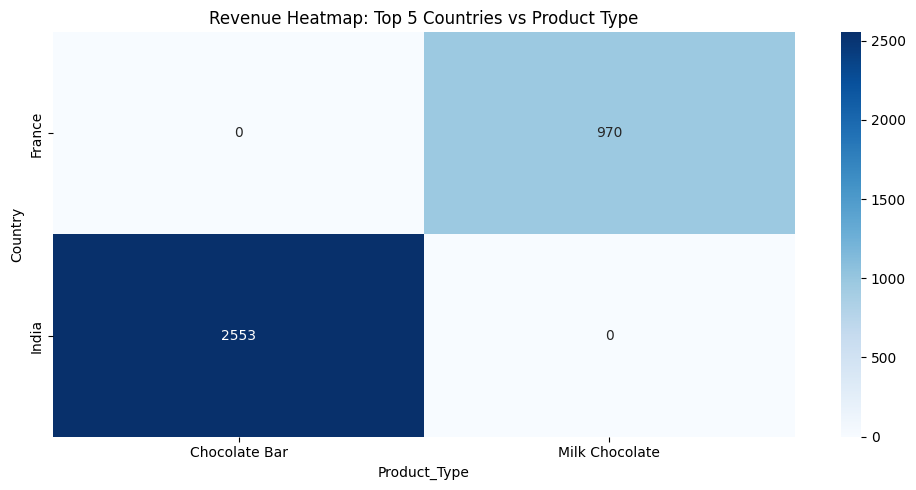

In [156]:
top_countries = df.groupby('Country')['Revenue_USD'].sum().nlargest(5).index
country_product = pd.pivot_table(df[df['Country'].isin(top_countries)],
                                 values='Revenue_USD', index='Country',
                                 columns='Product_Type', aggfunc='sum', fill_value=0)
plt.figure(figsize=(10,5))
sns.heatmap(country_product, annot=True, fmt='.0f', cmap='Blues')
plt.title('Revenue Heatmap: Top 5 Countries vs Product Type')
plt.tight_layout()
plt.show()

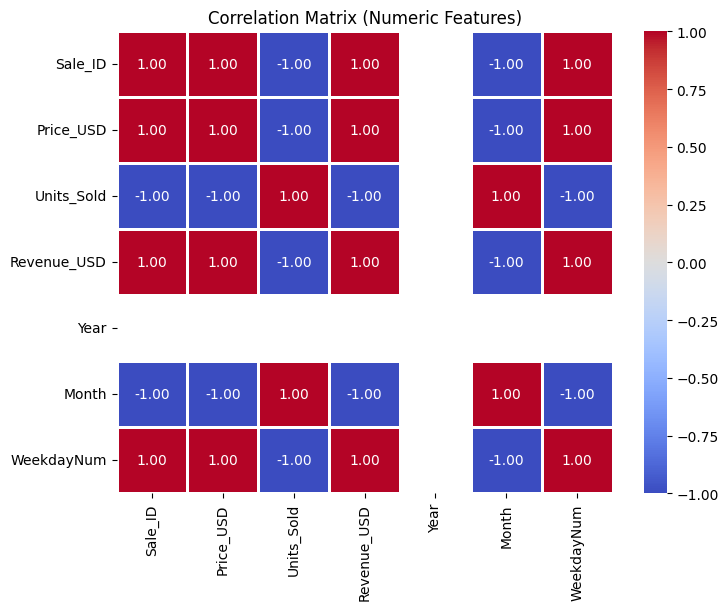

In [157]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Correlation Matrix (Numeric Features)')
plt.show()

In [158]:
top_products = df.groupby(['Country', 'Product_Type'])['Revenue_USD'].sum().reset_index()
top_products = top_products.sort_values(['Country', 'Revenue_USD'], ascending=[True, False])
top_3 = top_products.groupby('Country').head(3)
print("\nTop 3 product types by revenue in each country:")
print(top_3.to_string(index=False))


Top 3 product types by revenue in each country:
Country   Product_Type  Revenue_USD
 France Milk Chocolate       970.00
  India  Chocolate Bar      2553.12


In [159]:
channel_payment_ct = pd.crosstab(df['Sales_Channel'], df['Payment_Method'])
print("\nTransaction count by Sales Channel and Payment Method:")
print(channel_payment_ct)


Transaction count by Sales Channel and Payment Method:
Payment_Method  Cash  Digital Wallet
Sales_Channel                       
Online             1               0
Supermarket        0               1


In [160]:
df['Revenue_USD'].sum()
df['Units_Sold'].sum()
df['Price_USD'].mean()

np.float64(11.365)

In [161]:
df.groupby('Brand')['Revenue_USD'].sum().sort_values(ascending=False)

Brand
Lindt      2553.12
Cadbury     970.00
Name: Revenue_USD, dtype: float64

In [162]:
df.groupby('Country')['Revenue_USD'].sum()

Country
France     970.00
India     2553.12
Name: Revenue_USD, dtype: float64

In [165]:
df.columns = df.columns.str.strip()

In [168]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df.groupby('Month')['Revenue_USD'].sum()

Month
2     2553.12
11     970.00
Name: Revenue_USD, dtype: float64

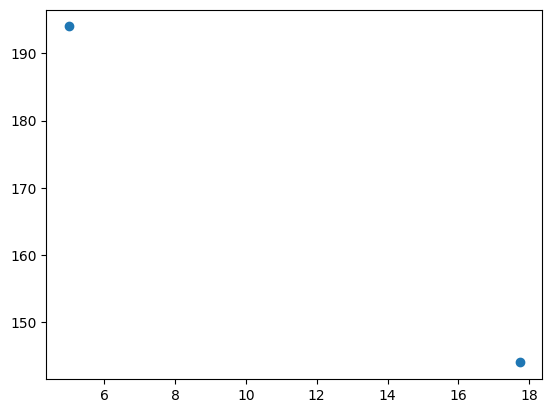

In [170]:
plt.scatter(df['Price_USD'], df['Units_Sold'])

In [171]:
df.sort_values('Revenue_USD', ascending=False).head(10)

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD,Year,Month,MonthName,Weekday,WeekdayNum
1,2,2025-02-22,Lindt,Chocolate Bar,India,Online,Cash,17.73,144,2553.12,2025,2,February,Saturday,5
0,1,2025-11-24,Cadbury,Milk Chocolate,France,Supermarket,Digital Wallet,5.00,194,970.00,2025,11,November,Monday,0


<Axes: xlabel='Brand', ylabel='Revenue_USD'>

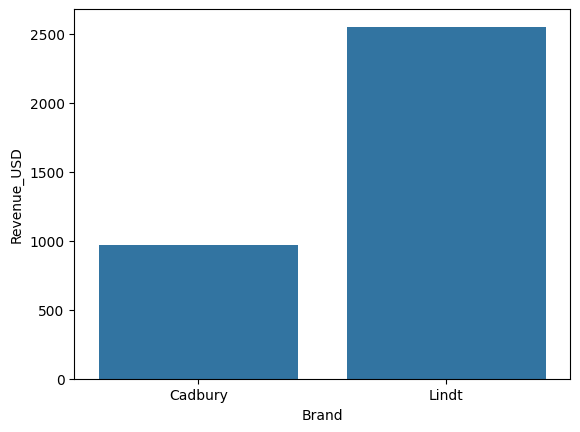

In [173]:

sns.barplot(x='Brand', y='Revenue_USD', data=df)

In [174]:
df.groupby('Sales_Channel')['Revenue_USD'].sum()

Sales_Channel
Online         2553.12
Supermarket     970.00
Name: Revenue_USD, dtype: float64

<Axes: xlabel='Sales_Channel', ylabel='Revenue_USD'>

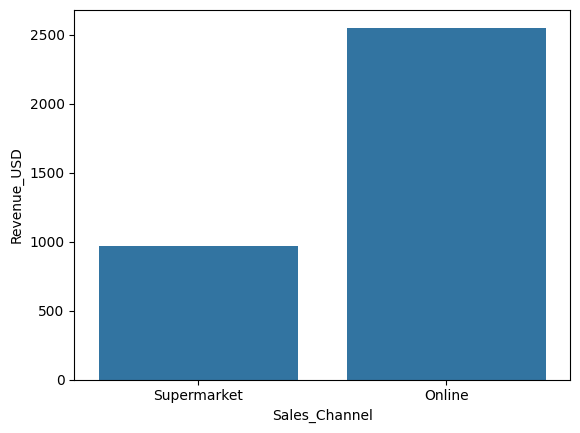

In [175]:

sns.barplot(x='Sales_Channel', y='Revenue_USD', data=df)

In [176]:
df.groupby('Payment_Method')['Revenue_USD'].sum()

Payment_Method
Cash              2553.12
Digital Wallet     970.00
Name: Revenue_USD, dtype: float64

In [177]:
df.groupby('Brand')['Units_Sold'].sum().sort_values(ascending=False)

Brand
Cadbury    194
Lindt      144
Name: Units_Sold, dtype: int64

In [178]:
df.groupby('Product_Type')['Revenue_USD'].sum()

Product_Type
Chocolate Bar     2553.12
Milk Chocolate     970.00
Name: Revenue_USD, dtype: float64

In [179]:
df.groupby('Country')['Units_Sold'].sum()

Country
France    194
India     144
Name: Units_Sold, dtype: int64

In [180]:
df.groupby('Brand')['Price_USD'].mean()

Brand
Cadbury     5.00
Lindt      17.73
Name: Price_USD, dtype: float64

In [181]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

df.groupby('Month')['Revenue_USD'].sum()

Month
2     2553.12
11     970.00
Name: Revenue_USD, dtype: float64

In [182]:
df.sort_values('Revenue_USD', ascending=False).head(10)

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD,Year,Month,MonthName,Weekday,WeekdayNum
1,2,2025-02-22,Lindt,Chocolate Bar,India,Online,Cash,17.73,144,2553.12,2025,2,February,Saturday,5
0,1,2025-11-24,Cadbury,Milk Chocolate,France,Supermarket,Digital Wallet,5.00,194,970.00,2025,11,November,Monday,0


<Axes: xlabel='Country', ylabel='Brand'>

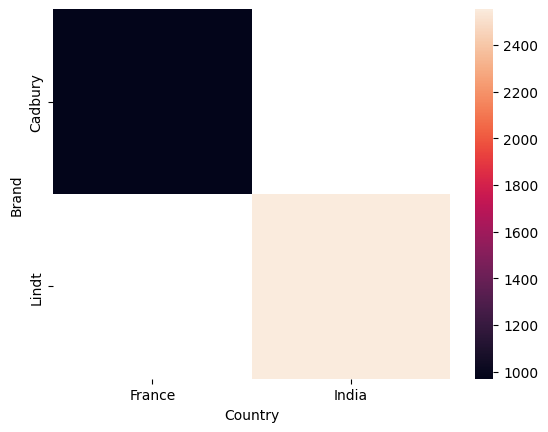

In [184]:
pivot = df.pivot_table(values='Revenue_USD', index='Brand', columns='Country', aggfunc='sum')

import seaborn as sns
sns.heatmap(pivot)

In [185]:
daily_sales = df.groupby('Date')['Revenue_USD'].sum()

daily_sales.head()

Date
2025-02-22    2553.12
2025-11-24     970.00
Name: Revenue_USD, dtype: float64

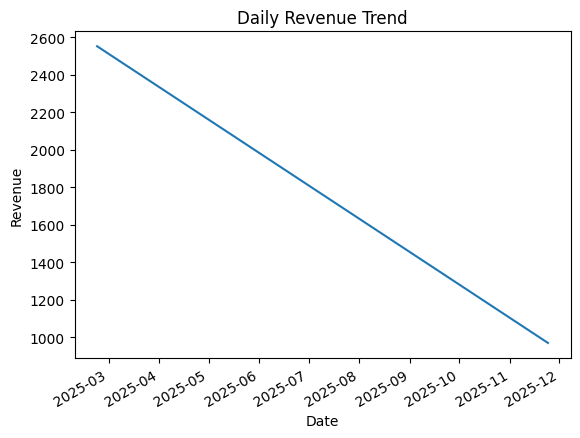

In [186]:
daily_sales.plot()
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [187]:
brand_share = df.groupby('Brand')['Revenue_USD'].sum()

brand_share

Brand
Cadbury     970.00
Lindt      2553.12
Name: Revenue_USD, dtype: float64

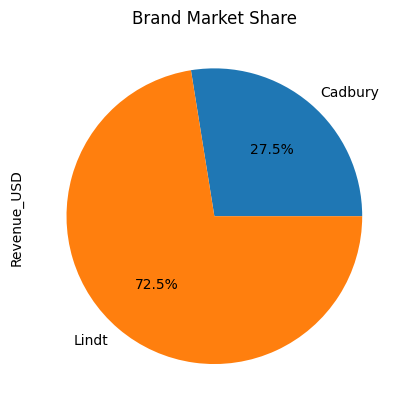

In [188]:
brand_share.plot(kind='pie', autopct='%1.1f%%')
plt.title("Brand Market Share")
plt.show()

In [189]:
top_country = df.groupby('Country')['Revenue_USD'].sum().sort_values(ascending=False)

top_country.head(10)

Country
India     2553.12
France     970.00
Name: Revenue_USD, dtype: float64

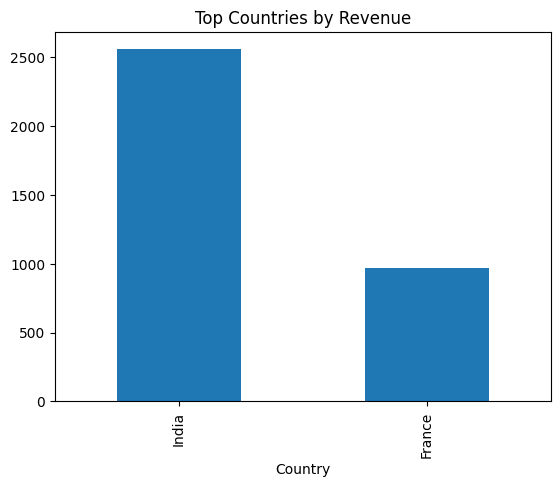

In [190]:
top_country.head(10).plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.show()

In [191]:
df['Units_Sold'].mean()

np.float64(169.0)

In [192]:
df.groupby('Brand')['Price_USD'].max().sort_values(ascending=False)

Brand
Lindt      17.73
Cadbury     5.00
Name: Price_USD, dtype: float64

In [193]:
df.groupby('Brand')['Price_USD'].min().sort_values()

Brand
Cadbury     5.00
Lindt      17.73
Name: Price_USD, dtype: float64

In [194]:
df.groupby('Sales_Channel')['Units_Sold'].sum()

Sales_Channel
Online         144
Supermarket    194
Name: Units_Sold, dtype: int64

<Axes: xlabel='Sales_Channel', ylabel='Units_Sold'>

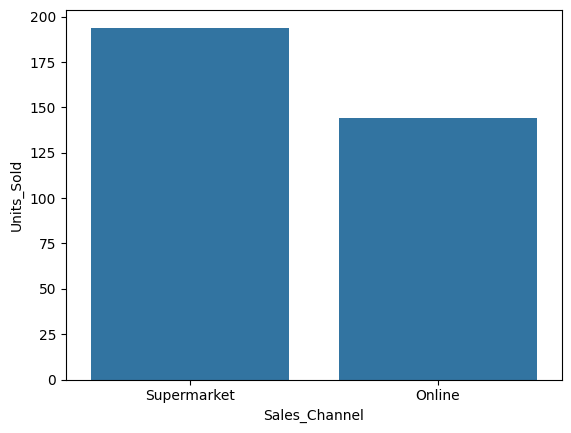

In [195]:


sns.barplot(x='Sales_Channel', y='Units_Sold', data=df)

In [196]:
df['Payment_Method'].value_counts()

Payment_Method
Digital Wallet    1
Cash              1
Name: count, dtype: int64

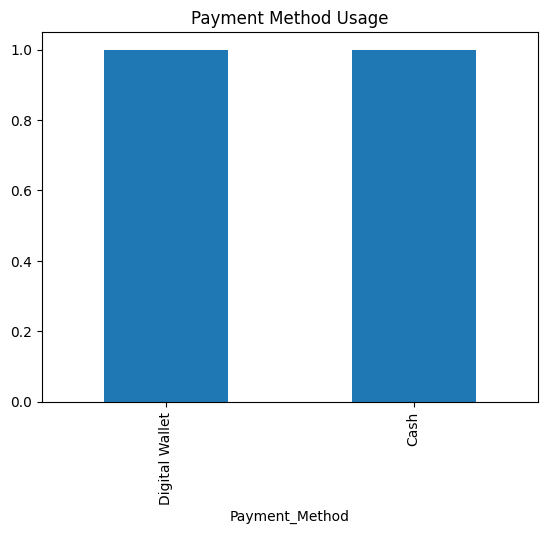

In [197]:
df['Payment_Method'].value_counts().plot(kind='bar')
plt.title("Payment Method Usage")
plt.show()

In [198]:
df.loc[df['Revenue_USD'].idxmax()]

Sale_ID                             2
Date              2025-02-22 00:00:00
Brand                           Lindt
Product_Type            Chocolate Bar
Country                         India
Sales_Channel                  Online
Payment_Method                   Cash
Price_USD                       17.73
Units_Sold                        144
Revenue_USD                   2553.12
Year                             2025
Month                               2
MonthName                    February
Weekday                      Saturday
WeekdayNum                          5
Name: 1, dtype: object

In [199]:
df[['Price_USD','Units_Sold','Revenue_USD']].corr()

,Price_USD,Units_Sold,Revenue_USD
Price_USD,1.0,-1.0,1.0
Units_Sold,-1.0,1.0,-1.0
Revenue_USD,1.0,-1.0,1.0


<Axes: >

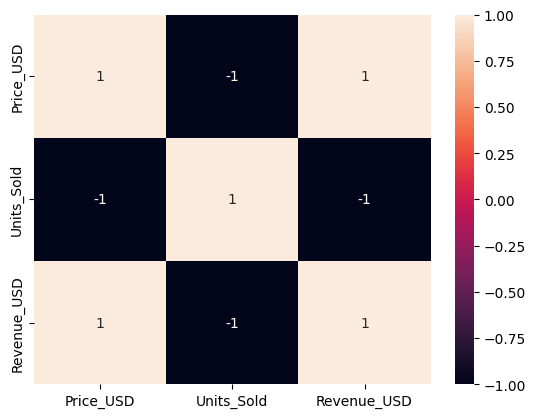

In [200]:
sns.heatmap(df[['Price_USD','Units_Sold','Revenue_USD']].corr(), annot=True)

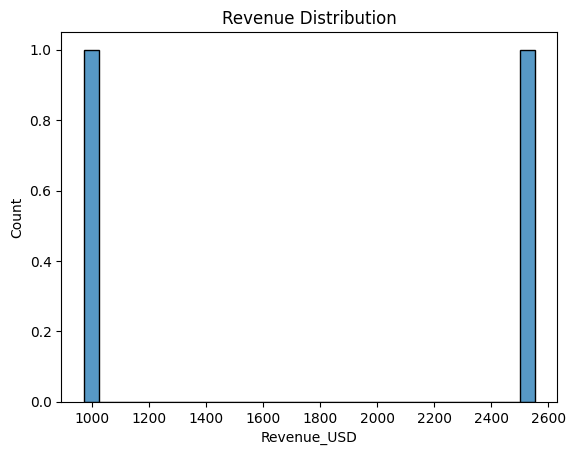

In [201]:
sns.histplot(df['Revenue_USD'], bins=30)
plt.title("Revenue Distribution")
plt.show()

In [202]:
from sklearn.linear_model import LinearRegression

In [205]:
sns.set_style("whitegrid")

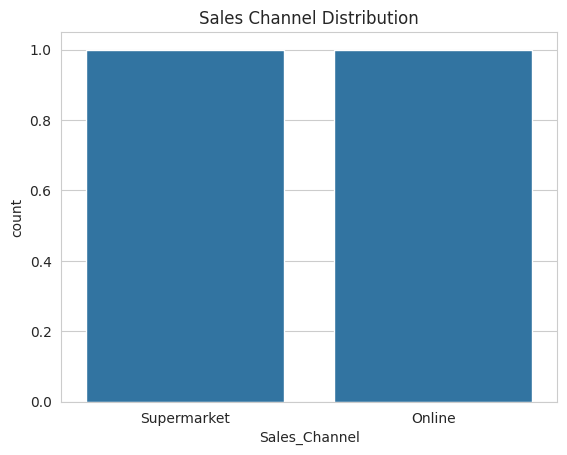

In [207]:
sns.countplot(x="Sales_Channel", data=df)
plt.title("Sales Channel Distribution")
plt.show()

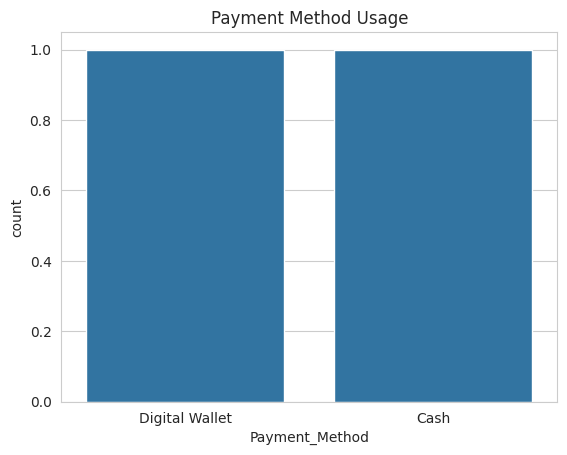

In [208]:
sns.countplot(x="Payment_Method", data=df)
plt.title("Payment Method Usage")
plt.show()

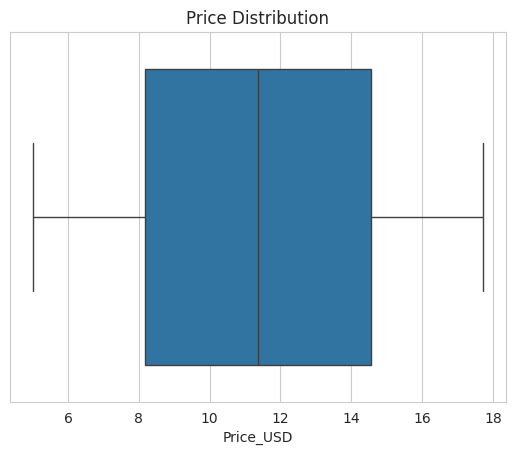

In [212]:
sns.boxplot(x=df['Price_USD'])
plt.title("Price Distribution")
plt.show()

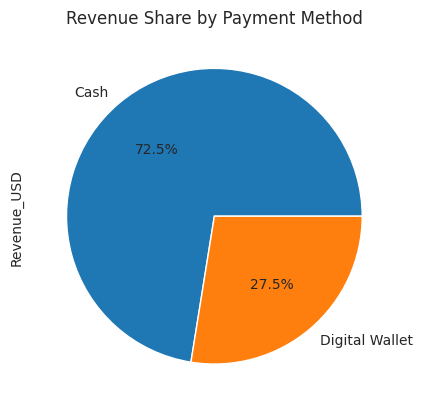

In [216]:
payment_revenue = df.groupby("Payment_Method")["Revenue_USD"].sum()

payment_revenue.plot(kind="pie", autopct='%1.1f%%')
plt.title("Revenue Share by Payment Method")
plt.show()

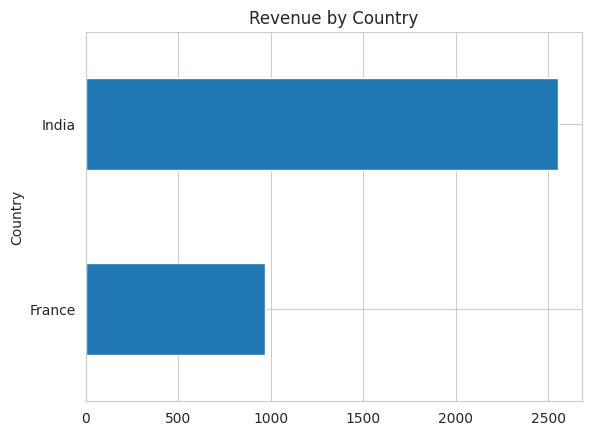

In [217]:
country_rev = df.groupby("Country")["Revenue_USD"].sum().sort_values()

country_rev.plot(kind="barh")
plt.title("Revenue by Country")
plt.show()

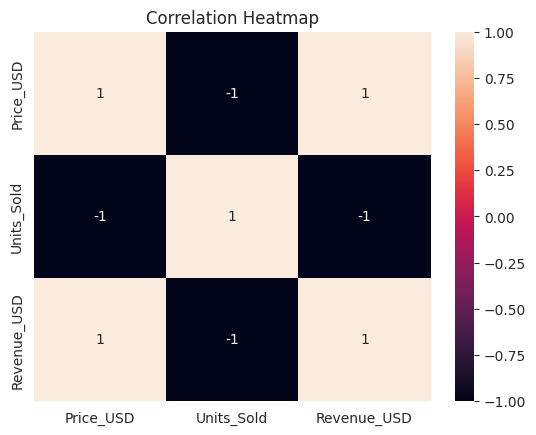

In [219]:
corr = df[['Price_USD','Units_Sold','Revenue_USD']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

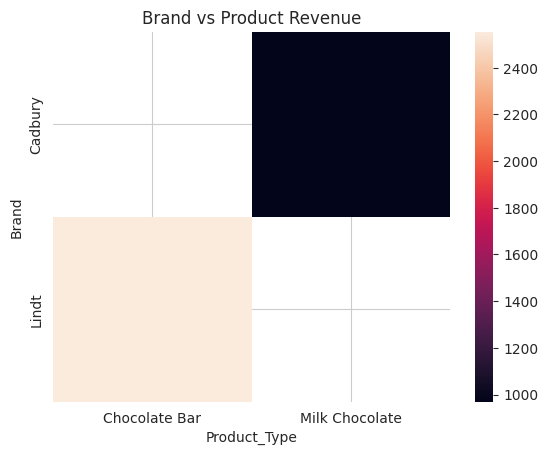

In [220]:
pivot = pd.pivot_table(df,
                       values="Revenue_USD",
                       index="Brand",
                       columns="Product_Type",
                       aggfunc="sum")

sns.heatmap(pivot)
plt.title("Brand vs Product Revenue")
plt.show()

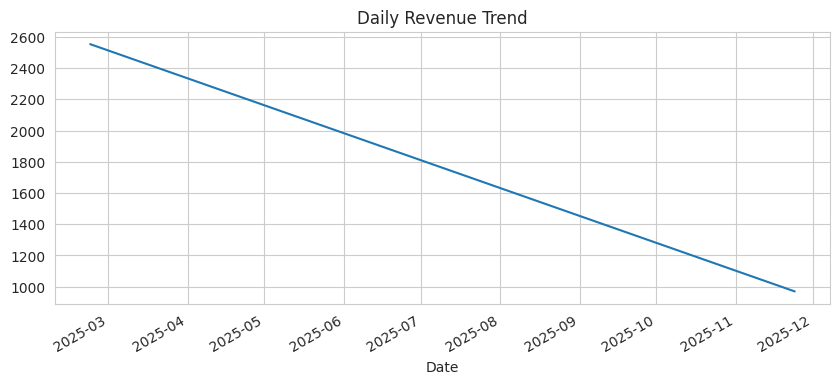

In [225]:
daily = df.groupby("Date")["Revenue_USD"].sum()

daily.plot(figsize=(10,4))
plt.title("Daily Revenue Trend")
plt.show()

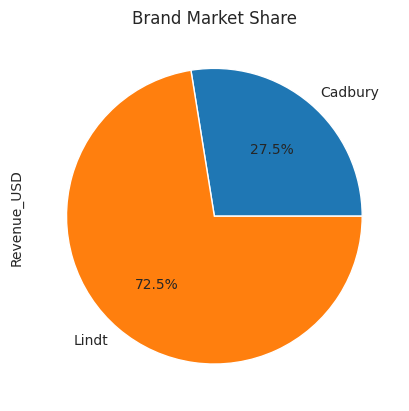

In [226]:
brand_share = df.groupby("Brand")["Revenue_USD"].sum()

brand_share.plot(kind="pie", autopct="%1.1f%%")
plt.title("Brand Market Share")
plt.show()

In [230]:
avg_order = df["Revenue_USD"].mean()
avg_order

np.float64(1761.56)